<a href="https://colab.research.google.com/github/pratyushsingh9870-arch/ML_lab/blob/main/lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4667 - loss: 1.0369
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5583 - loss: 0.9968
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5917 - loss: 0.9681
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6500 - loss: 0.9407
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6667 - loss: 0.9144
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6583 - loss: 0.8946
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6833 - loss: 0.8706
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6583 - loss: 0.8473
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7000 - loss: 0.8237
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7000 - loss: 0.8022
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7000 - loss: 0.7790
Epoch 12/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7000 -

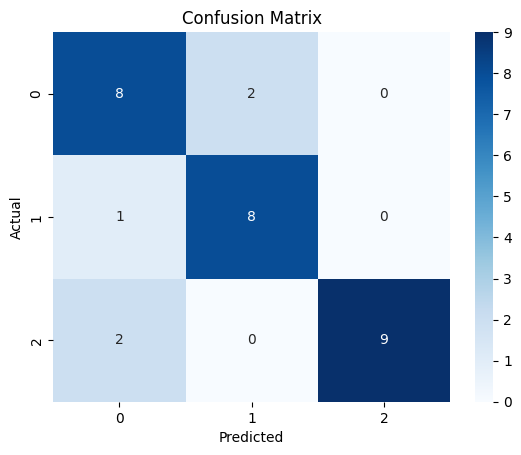

In [1]:
# ============================
# 🔹 IMPORT LIBRARIES
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# ============================
# 🔹 LOAD DATASET (AUTO)
# ============================
data = load_iris()
X = data.data
y = data.target

# ============================
# 🔹 ENCODING + ONE-HOT
# ============================
y = to_categorical(y)

# ============================
# 🔹 FEATURE SCALING
# ============================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ============================
# 🔹 RESHAPE FOR CNN
# ============================
X = X.reshape(X.shape[0], X.shape[1], 1)

# ============================
# 🔹 TRAIN-TEST SPLIT
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================
# 🔹 CNN MODEL
# ============================
model = Sequential()

model.add(Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(4,1)))
model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(16, activation='relu'))
model.add(Dense(3, activation='softmax'))

# ============================
# 🔹 COMPILE MODEL
# ============================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================
# 🔹 TRAIN MODEL
# ============================
history = model.fit(X_train, y_train, epochs=50, batch_size=5, verbose=1)

# ============================
# 🔹 PREDICTION
# ============================
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# ============================
# 🔹 EVALUATION
# ============================
print("Accuracy:", accuracy_score(y_test_classes, y_pred_classes))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_classes, y_pred_classes)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test_classes, y_pred_classes))

# ============================
# 🔹 HEATMAP
# ============================
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()